# Skenario 1 — Baseline Model (Tanpa Feature Selection & Dimensionality Reduction)

**Dataset**: Biological Age Predictive (Kaggle)  
**Target**: `Age_Group` (4 kelas hasil binning dari `Age (years)`)  

### Tujuan
Membangun **baseline** klasifikasi menggunakan **semua fitur** tanpa seleksi atau reduksi dimensi.  
Hasil skenario ini menjadi **acuan perbandingan** untuk skenario berikutnya.

### Model yang Dipilih
1. **Random Forest** — ensemble berbasis tree, robust terhadap overfitting dan tidak sensitif terhadap skala fitur
2. **K-Nearest Neighbors (KNN)** — instance-based learning, cocok untuk data yang sudah di-scale
3. **Support Vector Machine (SVM)** — efektif untuk klasifikasi multi-kelas dengan margin optimal

### Alasan Pemilihan
- Ketiga model mewakili paradigma berbeda: **ensemble**, **instance-based**, dan **margin-based**
- Random Forest sering menjadi baseline kuat di banyak kompetisi
- KNN dan SVM cocok karena data sudah di-StandardScaler
- Ketiganya tidak memerlukan asumsi distribusi data tertentu

In [1]:
# Ubah working directory ke root project agar path data sesuai
import os
if os.path.basename(os.getcwd()) == 'src':
    os.chdir('..')

In [2]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Library berhasil di-import ✅')

Library berhasil di-import ✅


---
## 1. Load Data Hasil Preprocessing
Data sudah melalui semua tahap preprocessing (encoding, scaling, binning) di notebook `00_preprocessing_binning.ipynb`.

In [3]:
# Load data yang sudah di-preprocessing
X_train = pd.read_csv('preprocessed_data/X_train.csv')
X_test  = pd.read_csv('preprocessed_data/X_test.csv')
y_train = pd.read_csv('preprocessed_data/y_train.csv').squeeze()

# Mapping label untuk interpretasi
LABEL_NAMES = {
    0: 'Dewasa Muda (18-35)',
    1: 'Dewasa (36-53)',
    2: 'Paruh Baya (54-71)',
    3: 'Lansia (72-89)'
}

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape} — {y_train.nunique()} kelas')
print(f'\nDistribusi kelas:')
for k, v in y_train.value_counts().sort_index().items():
    print(f'  {k} ({LABEL_NAMES[k]}): {v} ({v/len(y_train)*100:.1f}%)')

X_train : (3000, 35)
X_test  : (3000, 35)
y_train : (3000,) — 4 kelas

Distribusi kelas:
  0 (Dewasa Muda (18-35)): 726 (24.2%)
  1 (Dewasa (36-53)): 789 (26.3%)
  2 (Paruh Baya (54-71)): 726 (24.2%)
  3 (Lansia (72-89)): 759 (25.3%)


---
## 2. Setup Evaluasi
Karena dataset test **tidak memiliki label**, kita gunakan **Stratified 5-Fold Cross-Validation** pada data training untuk evaluasi yang fair. Stratified CV memastikan setiap fold memiliki proporsi kelas yang sama.

In [4]:
# Stratified K-Fold untuk evaluasi yang konsisten
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fungsi helper: evaluasi model lengkap dengan cross-validation
def evaluate_model(model, X, y, model_name):
    """Evaluasi model menggunakan cross-validation dan kembalikan metrik lengkap."""
    from sklearn.model_selection import cross_val_predict
    
    # Prediksi via cross-validation (setiap sampel diprediksi saat jadi test fold)
    y_pred = cross_val_predict(model, X, y, cv=cv)
    
    # Hitung metrik
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted')
    rec  = recall_score(y, y_pred, average='weighted')
    f1   = f1_score(y, y_pred, average='weighted')
    
    print(f'\n{"="*60}')
    print(f'MODEL: {model_name}')
    print(f'{"="*60}')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f} (weighted)')
    print(f'Recall    : {rec:.4f} (weighted)')
    print(f'F1-Score  : {f1:.4f} (weighted)')
    
    # Classification report per kelas
    target_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())]
    print(f'\nClassification Report:')
    print(classification_report(y, y_pred, target_names=target_names))
    
    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1_score': f1, 'y_pred': y_pred}

# Fungsi helper: plot confusion matrix sebagai heatmap
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Tampilkan confusion matrix sebagai heatmap yang informatif."""
    cm = confusion_matrix(y_true, y_pred)
    labels = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, linewidths=0.5, ax=ax)
    ax.set_xlabel('Prediksi', fontsize=12)
    ax.set_ylabel('Aktual', fontsize=12)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print('Fungsi evaluasi siap ✅')

Fungsi evaluasi siap ✅


---
## 3. Model 1 — Random Forest

**Mengapa Random Forest?**
- Merupakan ensemble dari banyak decision tree sehingga mengurangi risiko overfitting
- Mampu menangkap hubungan non-linear antar fitur
- Tidak sensitif terhadap skala fitur (meskipun data sudah di-scale)
- Sering digunakan sebagai strong baseline dalam data mining

In [5]:
# Inisialisasi model Random Forest dengan parameter default yang reasonable
rf_model = RandomForestClassifier(
    n_estimators=100,    # jumlah tree
    max_depth=None,      # biarkan tree tumbuh penuh
    random_state=42,
    n_jobs=-1            # gunakan semua CPU core
)

# Evaluasi
rf_results = evaluate_model(rf_model, X_train, y_train, 'Random Forest')


MODEL: Random Forest
Accuracy  : 0.8107
Precision : 0.8099 (weighted)
Recall    : 0.8107 (weighted)
F1-Score  : 0.8099 (weighted)

Classification Report:
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.87      0.87      0.87       726
     Dewasa (36-53)       0.74      0.77      0.76       789
 Paruh Baya (54-71)       0.76      0.70      0.73       726
     Lansia (72-89)       0.87      0.89      0.88       759

           accuracy                           0.81      3000
          macro avg       0.81      0.81      0.81      3000
       weighted avg       0.81      0.81      0.81      3000



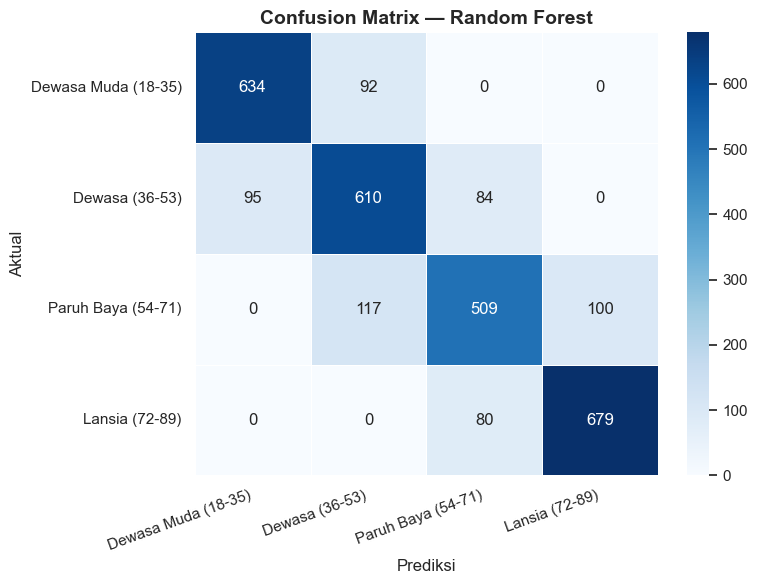

In [6]:
# Confusion matrix Random Forest
plot_confusion_matrix(y_train, rf_results['y_pred'], 'Random Forest')

### Interpretasi Random Forest
Perhatikan confusion matrix di atas:
- Kelas yang **paling mudah** diklasifikasikan terlihat dari diagonal utama yang nilainya tinggi
- **Misklasifikasi** terjadi terutama antar kelas yang **bersebelahan** (misalnya Dewasa Muda vs Dewasa), karena batas umur di antara kedua kelas memang tipis
- Ini wajar karena perbedaan biologis antara seseorang berumur 34 dan 36 tahun sangat kecil

---
## 4. Model 2 — K-Nearest Neighbors (KNN)

**Mengapa KNN?**
- Algoritma sederhana berbasis jarak yang memanfaatkan kemiripan antar sampel
- Bekerja optimal ketika fitur sudah di-StandardScaler (agar jarak antar fitur setara)
- Tidak mengasumsikan bentuk distribusi tertentu
- Berfungsi sebagai pembanding: apakah model yang lebih kompleks memberikan peningkatan?

In [7]:
# KNN dengan k=7 (pilihan umum — cukup besar untuk mengurangi noise,
# cukup kecil agar tetap sensitif terhadap pola lokal)
knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',  # bobot berdasarkan jarak — tetangga lebih dekat lebih berpengaruh
    n_jobs=-1
)

# Evaluasi
knn_results = evaluate_model(knn_model, X_train, y_train, 'KNN (k=7)')


MODEL: KNN (k=7)
Accuracy  : 0.6127
Precision : 0.6112 (weighted)
Recall    : 0.6127 (weighted)
F1-Score  : 0.6117 (weighted)

Classification Report:
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.72      0.72      0.72       726
     Dewasa (36-53)       0.52      0.54      0.53       789
 Paruh Baya (54-71)       0.49      0.45      0.47       726
     Lansia (72-89)       0.72      0.73      0.73       759

           accuracy                           0.61      3000
          macro avg       0.61      0.61      0.61      3000
       weighted avg       0.61      0.61      0.61      3000



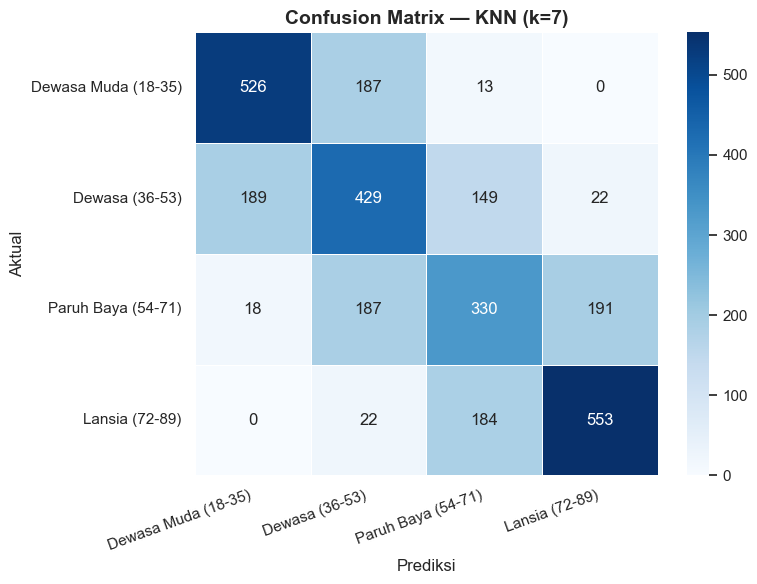

In [8]:
# Confusion matrix KNN
plot_confusion_matrix(y_train, knn_results['y_pred'], 'KNN (k=7)')

### Interpretasi KNN
- KNN mengandalkan **kedekatan jarak** antar sampel di ruang fitur 35-dimensi
- Performa KNN sangat bergantung pada kualitas fitur dan apakah fitur-fitur tersebut benar-benar relevan
- Jika banyak fitur yang **tidak informatif** (noise), KNN bisa terganggu karena "curse of dimensionality"
- Bandingkan hasilnya dengan Random Forest untuk melihat apakah model berbasis tree lebih unggul

---
## 5. Model 3 — Support Vector Machine (SVM)

**Mengapa SVM?**
- Mencari hyperplane optimal yang memisahkan kelas dengan margin terbesar
- Dengan kernel RBF, mampu menangkap hubungan non-linear yang kompleks
- Efektif pada data berdimensi tinggi (35 fitur)
- Memberikan perspektif berbeda dari Random Forest (tree-based) dan KNN (distance-based)

In [9]:
# SVM dengan kernel RBF (Radial Basis Function)
svm_model = SVC(
    kernel='rbf',
    C=1.0,               # parameter regularisasi
    gamma='scale',       # otomatis 1/(n_features * var)
    random_state=42
)

# Evaluasi
svm_results = evaluate_model(svm_model, X_train, y_train, 'SVM (RBF)')


MODEL: SVM (RBF)
Accuracy  : 0.8000
Precision : 0.7985 (weighted)
Recall    : 0.8000 (weighted)
F1-Score  : 0.7990 (weighted)

Classification Report:
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.87      0.87      0.87       726
     Dewasa (36-53)       0.73      0.75      0.74       789
 Paruh Baya (54-71)       0.73      0.69      0.71       726
     Lansia (72-89)       0.86      0.90      0.88       759

           accuracy                           0.80      3000
          macro avg       0.80      0.80      0.80      3000
       weighted avg       0.80      0.80      0.80      3000



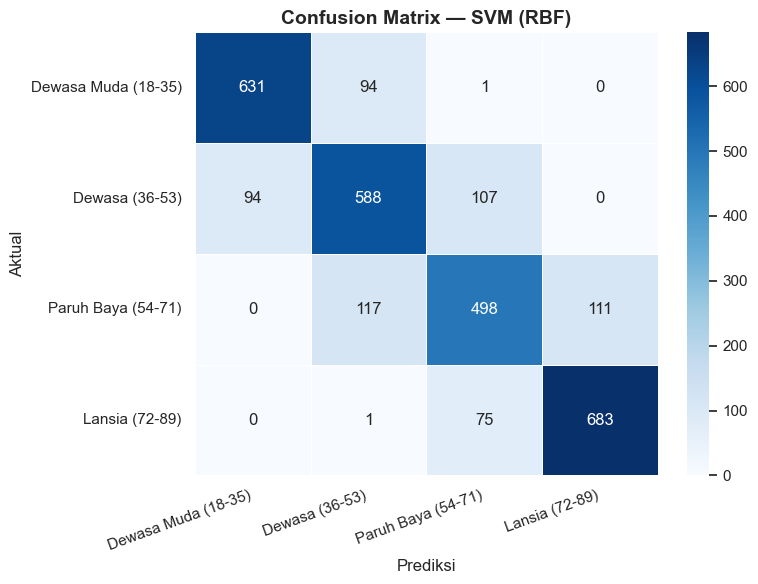

In [10]:
# Confusion matrix SVM
plot_confusion_matrix(y_train, svm_results['y_pred'], 'SVM (RBF)')

### Interpretasi SVM
- SVM dengan kernel RBF memetakan data ke dimensi yang lebih tinggi untuk menemukan batas keputusan non-linear
- Perhatikan apakah SVM lebih baik dari Random Forest — jika ya, ini menunjukkan bahwa batas antar kelas bersifat non-linear dan dapat dipisahkan dengan margin yang jelas
- Jika performanya lebih rendah, kemungkinan parameter default belum optimal (bisa ditingkatkan di skenario lanjutan)

---
## 6. Perbandingan Performa Antar Model
Tabel ringkas untuk membandingkan ketiga model baseline.

In [11]:
# Buat tabel perbandingan
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [rf_results, knn_results, svm_results]
]).set_index('model')

# Format sebagai persentase
comparison_pct = comparison.copy()
for col in comparison_pct.columns:
    comparison_pct[col] = comparison_pct[col].apply(lambda x: f'{x:.4f} ({x*100:.2f}%)')

print('=' * 70)
print('PERBANDINGAN PERFORMA BASELINE MODELS')
print('=' * 70)
print(comparison_pct.to_string())

# Tentukan model terbaik berdasarkan F1-score
best_model = comparison['f1_score'].idxmax()
best_f1 = comparison.loc[best_model, 'f1_score']
print(f'\n🏆 Model terbaik: {best_model} (F1-Score = {best_f1:.4f})')

PERBANDINGAN PERFORMA BASELINE MODELS
                      accuracy        precision           recall         f1_score
model                                                                            
Random Forest  0.8107 (81.07%)  0.8099 (80.99%)  0.8107 (81.07%)  0.8099 (80.99%)
KNN (k=7)      0.6127 (61.27%)  0.6112 (61.12%)  0.6127 (61.27%)  0.6117 (61.17%)
SVM (RBF)      0.8000 (80.00%)  0.7985 (79.85%)  0.8000 (80.00%)  0.7990 (79.90%)

🏆 Model terbaik: Random Forest (F1-Score = 0.8099)


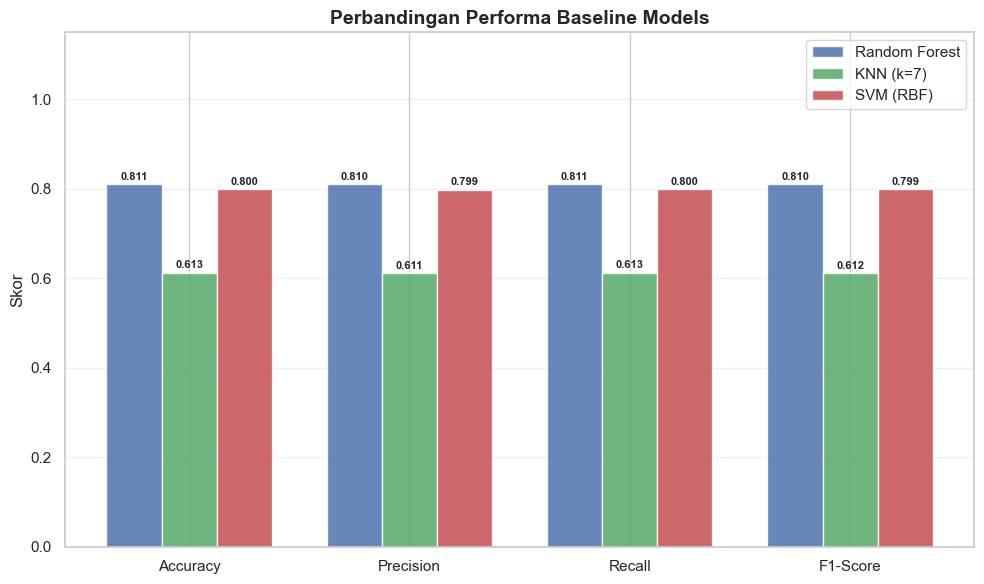

In [12]:
# Visualisasi perbandingan metrik antar model
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']
models = comparison.index.tolist()

for i, model in enumerate(models):
    vals = [comparison.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors[i], alpha=0.85)
    # Label di atas bar
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Baseline Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Simpan Hasil Baseline untuk Referensi
Nilai-nilai ini akan digunakan sebagai **acuan perbandingan** di skenario berikutnya.

In [13]:
# Simpan tabel perbandingan ke CSV
comparison.to_csv('baseline_results.csv')
print('Hasil baseline tersimpan di: baseline_results.csv ✅')
print()
print(comparison.round(4).to_string())

Hasil baseline tersimpan di: baseline_results.csv ✅

               accuracy  precision  recall  f1_score
model                                               
Random Forest    0.8107     0.8099  0.8107    0.8099
KNN (k=7)        0.6127     0.6112  0.6127    0.6117
SVM (RBF)        0.8000     0.7985  0.8000    0.7990


---
## 8. Kesimpulan Skenario 1

### Temuan Utama
1. **Ketiga model** dijalankan pada **semua 35 fitur** tanpa seleksi atau reduksi dimensi
2. Evaluasi menggunakan **Stratified 5-Fold CV** untuk hasil yang reliable
3. Distribusi kelas yang **seimbang** (~25% per kelas) memudahkan evaluasi fair tanpa perlu teknik oversampling

### Catatan untuk Skenario Berikutnya
- Skenario 2: Apakah **feature selection** dapat meningkatkan performa?
- Skenario 3: Apakah **dimensionality reduction** (PCA, dll.) membantu?
- Semua peningkatan akan dibandingkan terhadap **baseline** yang tercatat di notebook ini

### Referensi Baseline
Lihat tabel perbandingan di atas dan file `baseline_results.csv` untuk nilai acuan.